In [1]:
import pandas as pd
import numpy as np
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Dropout, Add, Activation
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import os
import json 

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
import pandas as pd
import joblib
import os

# ==========================================
# 📥 1. โหลดข้อมูลและตัวแปรที่คัดมาแล้ว
# ==========================================

# 1.1 ใส่ Path ข้อมูลของตัวเอง (แก้ path ให้ตรงกับเครื่องตัวเองนะคะ)
path = '/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/Data_Split/' 

# โหลดข้อมูล X_train, y_train, X_test, y_test เข้ามา
# (สมมติว่าตัวเองมีไฟล์ test แยกไว้แล้ว ถ้าไม่มีก็โหลดตัวเต็มมา split ใหม่ได้ค่ะ)
X_train_full = pd.read_csv(f'{path}X_train_90.csv')
y_train = pd.read_csv(f'{path}y_train_90.csv').squeeze() # .squeeze() เพื่อให้เป็น Series
X_test_full = pd.read_csv(f'{path}X_test_10.csv')      # ถ้าชื่อไฟล์ test ไม่ตรง แก้ได้เลยนะคะ
y_test = pd.read_csv(f'{path}y_test_10.csv').squeeze()

# -------------------------------------------------------
# 🔥 ไฮไลท์: โหลด "10 ตัวเทพ" ที่ RFE เลือกไว้มาใช้
# -------------------------------------------------------
# ต้องมั่นใจว่าไฟล์ pkl อยู่ในโฟลเดอร์ models หรือ path เดียวกัน
selected_features = joblib.load('models/rfe_rf_features.pkl')

print(f"✅ โหลดตัวแปรที่คัดเลือกมาแล้ว {len(selected_features)} ตัว:")
print(selected_features)

# 1.2 กรองข้อมูลให้เหลือแค่ 10 ตัวนี้
X_train = X_train_full[selected_features]
X_test = X_test_full[selected_features]

print("\n------------------------------------------------")
print(f"Shape ข้อมูลพร้อมเทรน:")
print(f"X_train: {X_train.shape}  <-- สังเกตว่าคอลัมน์จะเหลือแค่ 10")
print(f"X_test:  {X_test.shape}")
print("------------------------------------------------")

✅ โหลดตัวแปรที่คัดเลือกมาแล้ว 10 ตัว:
['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Alcohol Consumption', 'Sleep Hours', 'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level']

------------------------------------------------
Shape ข้อมูลพร้อมเทรน:
X_train: (9000, 10)  <-- สังเกตว่าคอลัมน์จะเหลือแค่ 10
X_test:  (1000, 10)
------------------------------------------------


In [3]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Add, Activation
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ฟังก์ชันสร้าง ResNet Block
def residual_block(x, units, dropout_rate=0.2):
    shortcut = x
    
    # Layer 1
    x = Dense(units)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)
    
    # Layer 2
    x = Dense(units)(x)
    x = BatchNormalization()(x)
    
    # Skip Connection (หัวใจสำคัญของ ResNet)
    # ถ้าขนาดไม่เท่ากัน ปรับขนาด shortcut ให้เท่ากันก่อนบวก
    if shortcut.shape[-1] != units:
        shortcut = Dense(units)(shortcut)
        
    x = Add()([x, shortcut]) # บวกค่าเดิมกลับเข้าไป
    x = Activation('relu')(x)
    return x

# ฟังก์ชันสร้างโมเดลหลัก
def create_resnet_model(input_dim):
    inputs = Input(shape=(input_dim,))
    
    # Project Input
    x = Dense(64)(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    
    # Stack Residual Blocks (ต่อบล็อกซ้อนกัน)
    x = residual_block(x, units=64, dropout_rate=0.3)
    x = residual_block(x, units=32, dropout_rate=0.3)
    x = residual_block(x, units=16, dropout_rate=0.2)
    
    # Output Layer
    outputs = Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[
            'accuracy', 
            tf.keras.metrics.Precision(name='precision'), 
            tf.keras.metrics.Recall(name='recall'), 
            tf.keras.metrics.AUC(name='auc')
        ]
    )
    return model

print("✓ ResNet Architecture Created!")

✓ ResNet Architecture Created!


------------------------------
ResNet - Baseline (No Sampling)
------------------------------


Fold 1: Val Accuracy = 0.8000 (Recall: 0.0000)


Fold 2: Val Accuracy = 0.8000 (Recall: 0.0000)


Fold 3: Val Accuracy = 0.8000 (Recall: 0.0000)


Fold 4: Val Accuracy = 0.8000 (Recall: 0.0000)


Fold 5: Val Accuracy = 0.8000 (Recall: 0.0000)
Selected model from fold 1 for test evaluation


--- Test Set Performance ---
              precision    recall  f1-score   support

           0     0.8000    1.0000    0.8889       800
           1     0.0000    0.0000    0.0000       200

    accuracy                         0.8000      1000
   macro avg     0.4000    0.5000    0.4444      1000
weighted avg     0.6400    0.8000    0.7111      1000

Confusion Matrix:
 [[800   0]
 [200   0]]


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` paramete

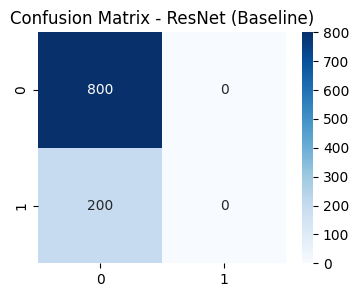

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


✓ ResNet Baseline Done


In [4]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

print("-" * 30)
print('ResNet - Baseline (No Sampling)')
print("-" * 30)

best_model_resnet_base = None
best_score_resnet_base = 0
best_fold_idx_resnet_base = -1
cv_scores = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    # สร้างโมเดล ResNet
    model = create_resnet_model(X_fold_train.shape[1])
    
    # Callbacks
    early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=0)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=0)
    
    # Train
    model.fit(
        X_fold_train, y_fold_train,
        validation_data=(X_fold_val, y_fold_val),
        epochs=100,
        batch_size=32,
        callbacks=[early_stopping, reduce_lr],
        verbose=0
    )
    
    # Evaluate
    loss, accuracy, precision, recall, auc = model.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_scores.append(accuracy)
    print(f"Fold {fold}: Val Accuracy = {accuracy:.4f} (Recall: {recall:.4f})")
    
    if accuracy > best_score_resnet_base:
        best_score_resnet_base = accuracy
        best_model_resnet_base = model
        best_fold_idx_resnet_base = fold

# Test Set Evaluation
print(f"Selected model from fold {best_fold_idx_resnet_base} for test evaluation")
y_pred_proba = best_model_resnet_base.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()
print('--- Test Set Performance ---')
print(classification_report(y_test, y_pred, digits=4))
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:\n', cm)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - ResNet (Baseline)')
plt.show()

resnet_baseline_results = {
    'Model': 'ResNet',
    'Sampling': 'None (Baseline)',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1_Score': f1_score(y_test, y_pred),
    'ROC_AUC': roc_auc_score(y_test, y_pred_proba),
    'TP': confusion_matrix(y_test, y_pred).ravel()[3],
    'TN': confusion_matrix(y_test, y_pred).ravel()[0],
    'FP': confusion_matrix(y_test, y_pred).ravel()[1],
    'FN': confusion_matrix(y_test, y_pred).ravel()[2]
}

# Save
os.makedirs('resnet/models', exist_ok=True)
best_model_resnet_base.save('resnet/models/ResNet_baseline_bestfold.h5')
print("✓ ResNet Baseline Done")

------------------------------
ResNet + SMOTE
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 1: Val Accuracy = 0.6294


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 2: Val Accuracy = 0.5928


...

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 4: Val Accuracy = 0.6111


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 5: Val Accuracy = 0.6067
Selected model from fold 1 for test evaluation


--- Test Set Performance ---
              precision    recall  f1-score   support

           0     0.7971    0.6875    0.7383       800
           1     0.1935    0.3000    0.2353       200

    accuracy                         0.6100      1000
   macro avg     0.4953    0.4938    0.4868      1000
weighted avg     0.6764    0.6100    0.6377      1000

Confusion Matrix:
 [[550 250]
 [140  60]]


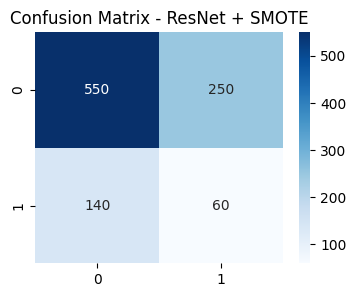

✓ Done: ResNet + SMOTE


In [5]:
from imblearn.over_sampling import SMOTE

print("-" * 30)
print('ResNet + SMOTE')
print("-" * 30)

best_model_resnet_smote = None
best_score_resnet_smote = 0
best_fold_idx_resnet_smote = -1
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    smote = SMOTE(random_state=42)
    X_res, y_res = smote.fit_resample(X_fold_train, y_fold_train)
    
    model = create_resnet_model(X_res.shape[1])
    model.fit(X_res, y_res, validation_data=(X_fold_val, y_fold_val),
              epochs=50, batch_size=32, verbose=0,
              callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)])
    
    loss, accuracy, precision, recall, auc = model.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_scores.append(accuracy)
    print(f"Fold {fold}: Val Accuracy = {accuracy:.4f}")
    
    if accuracy > best_score_resnet_smote:
        best_score_resnet_smote = accuracy
        best_model_resnet_smote = model
        best_fold_idx_resnet_smote = fold

print(f"Selected model from fold {best_fold_idx_resnet_smote} for test evaluation")
y_pred_proba = best_model_resnet_smote.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()
print('--- Test Set Performance ---')
print(classification_report(y_test, y_pred, digits=4))
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:\n', cm)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - ResNet + SMOTE')
plt.show()

resnet_smote_results = {
    'Model': 'ResNet', 'Sampling': f'SMOTE (Fold {best_fold_idx_resnet_smote})',
    'CV_Accuracy': np.mean(cv_scores), 'CV_Std': np.std(cv_scores),
    'Test_Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred), 'Recall': recall_score(y_test, y_pred),
    'F1_Score': f1_score(y_test, y_pred), 'ROC_AUC': roc_auc_score(y_test, y_pred_proba),
    'TP': confusion_matrix(y_test, y_pred).ravel()[3], 'TN': confusion_matrix(y_test, y_pred).ravel()[0],
    'FP': confusion_matrix(y_test, y_pred).ravel()[1], 'FN': confusion_matrix(y_test, y_pred).ravel()[2]
}
best_model_resnet_smote.save('resnet/models/ResNet_smote_bestfold.h5')
print("✓ Done: ResNet + SMOTE")

------------------------------
ResNet + ADASYN
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 1: Val Accuracy = 0.5167


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 2: Val Accuracy = 0.5739


...

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 4: Val Accuracy = 0.6117


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 5: Val Accuracy = 0.6044
Selected model from fold 4 for test evaluation


--- Test Set Performance ---
              precision    recall  f1-score   support

           0     0.8044    0.7250    0.7627       800
           1     0.2115    0.2950    0.2463       200

    accuracy                         0.6390      1000
   macro avg     0.5080    0.5100    0.5045      1000
weighted avg     0.6858    0.6390    0.6594      1000

Confusion Matrix:
 [[580 220]
 [141  59]]


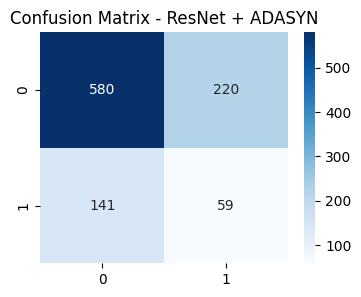

✓ Done: ResNet + ADASYN


In [6]:
from imblearn.over_sampling import ADASYN

print("-" * 30)
print('ResNet + ADASYN')
print("-" * 30)

best_model_resnet_adasyn = None
best_score_resnet_adasyn = 0
best_fold_idx_resnet_adasyn = -1
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    adasyn = ADASYN(random_state=42)
    X_res, y_res = adasyn.fit_resample(X_fold_train, y_fold_train)
    
    model = create_resnet_model(X_res.shape[1])
    model.fit(X_res, y_res, validation_data=(X_fold_val, y_fold_val),
              epochs=50, batch_size=32, verbose=0,
              callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)])
    
    loss, accuracy, precision, recall, auc = model.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_scores.append(accuracy)
    print(f"Fold {fold}: Val Accuracy = {accuracy:.4f}")
    
    if accuracy > best_score_resnet_adasyn:
        best_score_resnet_adasyn = accuracy
        best_model_resnet_adasyn = model
        best_fold_idx_resnet_adasyn = fold

print(f"Selected model from fold {best_fold_idx_resnet_adasyn} for test evaluation")
y_pred_proba = best_model_resnet_adasyn.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()
print('--- Test Set Performance ---')
print(classification_report(y_test, y_pred, digits=4))
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:\n', cm)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - ResNet + ADASYN')
plt.show()

resnet_adasyn_results = {
    'Model': 'ResNet', 'Sampling': f'ADASYN (Fold {best_fold_idx_resnet_adasyn})',
    'CV_Accuracy': np.mean(cv_scores), 'CV_Std': np.std(cv_scores),
    'Test_Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred), 'Recall': recall_score(y_test, y_pred),
    'F1_Score': f1_score(y_test, y_pred), 'ROC_AUC': roc_auc_score(y_test, y_pred_proba),
    'TP': confusion_matrix(y_test, y_pred).ravel()[3], 'TN': confusion_matrix(y_test, y_pred).ravel()[0],
    'FP': confusion_matrix(y_test, y_pred).ravel()[1], 'FN': confusion_matrix(y_test, y_pred).ravel()[2]
}
best_model_resnet_adasyn.save('resnet/models/ResNet_adasyn_bestfold.h5')
print("✓ Done: ResNet + ADASYN")

------------------------------
ResNet + RandomUnderSampler
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


Fold 1: Val Accuracy = 0.5117


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


Fold 2: Val Accuracy = 0.6039


...

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


Fold 4: Val Accuracy = 0.5544


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


Fold 5: Val Accuracy = 0.5994
Selected model from fold 2 for test evaluation


--- Test Set Performance ---
              precision    recall  f1-score   support

           0     0.7946    0.6238    0.6989       800
           1     0.1909    0.3550    0.2483       200

    accuracy                         0.5700      1000
   macro avg     0.4927    0.4894    0.4736      1000
weighted avg     0.6738    0.5700    0.6088      1000

Confusion Matrix:
 [[499 301]
 [129  71]]


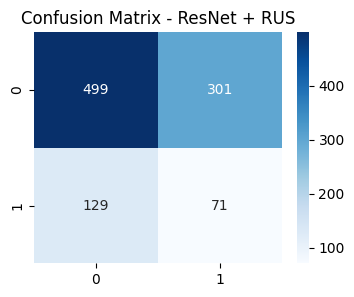

✓ Done: ResNet + RUS


In [7]:
from imblearn.under_sampling import RandomUnderSampler

print("-" * 30)
print('ResNet + RandomUnderSampler')
print("-" * 30)

best_model_resnet_rus = None
best_score_resnet_rus = 0
best_fold_idx_resnet_rus = -1
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    rus = RandomUnderSampler(random_state=42)
    X_res, y_res = rus.fit_resample(X_fold_train, y_fold_train)
    
    model = create_resnet_model(X_res.shape[1])
    model.fit(X_res, y_res, validation_data=(X_fold_val, y_fold_val),
              epochs=50, batch_size=32, verbose=0,
              callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)])
    
    loss, accuracy, precision, recall, auc = model.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_scores.append(accuracy)
    print(f"Fold {fold}: Val Accuracy = {accuracy:.4f}")
    
    if accuracy > best_score_resnet_rus:
        best_score_resnet_rus = accuracy
        best_model_resnet_rus = model
        best_fold_idx_resnet_rus = fold

print(f"Selected model from fold {best_fold_idx_resnet_rus} for test evaluation")
y_pred_proba = best_model_resnet_rus.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()
print('--- Test Set Performance ---')
print(classification_report(y_test, y_pred, digits=4))
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:\n', cm)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - ResNet + RUS')
plt.show()

resnet_rus_results = {
    'Model': 'ResNet', 'Sampling': f'RandomUnderSampler (Fold {best_fold_idx_resnet_rus})',
    'CV_Accuracy': np.mean(cv_scores), 'CV_Std': np.std(cv_scores),
    'Test_Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred), 'Recall': recall_score(y_test, y_pred),
    'F1_Score': f1_score(y_test, y_pred), 'ROC_AUC': roc_auc_score(y_test, y_pred_proba),
    'TP': confusion_matrix(y_test, y_pred).ravel()[3], 'TN': confusion_matrix(y_test, y_pred).ravel()[0],
    'FP': confusion_matrix(y_test, y_pred).ravel()[1], 'FN': confusion_matrix(y_test, y_pred).ravel()[2]
}
best_model_resnet_rus.save('resnet/models/ResNet_rus_bestfold.h5')
print("✓ Done: ResNet + RUS")

------------------------------
ResNet + NearMiss
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 1: Val Accuracy = 0.3244


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 2: Val Accuracy = 0.5100


...

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 4: Val Accuracy = 0.5711


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 5: Val Accuracy = 0.5206
Selected model from fold 4 for test evaluation


--- Test Set Performance ---
              precision    recall  f1-score   support

           0     0.7970    0.5938    0.6805       800
           1     0.1955    0.3950    0.2616       200

    accuracy                         0.5540      1000
   macro avg     0.4963    0.4944    0.4711      1000
weighted avg     0.6767    0.5540    0.5967      1000

Confusion Matrix:
 [[475 325]
 [121  79]]


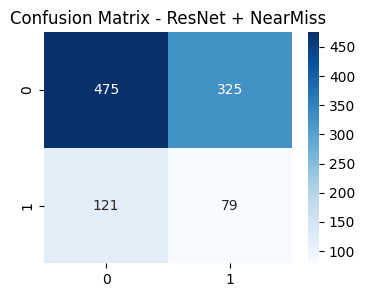

✓ Done: ResNet + NearMiss


In [8]:
from imblearn.under_sampling import NearMiss

print("-" * 30)
print('ResNet + NearMiss')
print("-" * 30)

best_model_resnet_nm = None
best_score_resnet_nm = 0
best_fold_idx_resnet_nm = -1
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    nm = NearMiss(version=1)
    X_res, y_res = nm.fit_resample(X_fold_train, y_fold_train)
    
    model = create_resnet_model(X_res.shape[1])
    model.fit(X_res, y_res, validation_data=(X_fold_val, y_fold_val),
              epochs=50, batch_size=32, verbose=0,
              callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)])
    
    loss, accuracy, precision, recall, auc = model.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_scores.append(accuracy)
    print(f"Fold {fold}: Val Accuracy = {accuracy:.4f}")
    
    if accuracy > best_score_resnet_nm:
        best_score_resnet_nm = accuracy
        best_model_resnet_nm = model
        best_fold_idx_resnet_nm = fold

print(f"Selected model from fold {best_fold_idx_resnet_nm} for test evaluation")
y_pred_proba = best_model_resnet_nm.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()
print('--- Test Set Performance ---')
print(classification_report(y_test, y_pred, digits=4))
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:\n', cm)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - ResNet + NearMiss')
plt.show()

resnet_nearmiss_results = {
    'Model': 'ResNet', 'Sampling': f'NearMiss (Fold {best_fold_idx_resnet_nm})',
    'CV_Accuracy': np.mean(cv_scores), 'CV_Std': np.std(cv_scores),
    'Test_Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred), 'Recall': recall_score(y_test, y_pred),
    'F1_Score': f1_score(y_test, y_pred), 'ROC_AUC': roc_auc_score(y_test, y_pred_proba),
    'TP': confusion_matrix(y_test, y_pred).ravel()[3], 'TN': confusion_matrix(y_test, y_pred).ravel()[0],
    'FP': confusion_matrix(y_test, y_pred).ravel()[1], 'FN': confusion_matrix(y_test, y_pred).ravel()[2]
}
best_model_resnet_nm.save('resnet/models/ResNet_nearmiss_bestfold.h5')
print("✓ Done: ResNet + NearMiss")

------------------------------
ResNet + ClusterCentroids (Warning: Slow!)
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 1: Val Accuracy = 0.5572


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 2: Val Accuracy = 0.6550


...

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 4: Val Accuracy = 0.5289


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 5: Val Accuracy = 0.5578
Selected model from fold 2 for test evaluation


--- Test Set Performance ---
              precision    recall  f1-score   support

           0     0.7909    0.7425    0.7660       800
           1     0.1727    0.2150    0.1915       200

    accuracy                         0.6370      1000
   macro avg     0.4818    0.4788    0.4787      1000
weighted avg     0.6673    0.6370    0.6511      1000

Confusion Matrix:
 [[594 206]
 [157  43]]


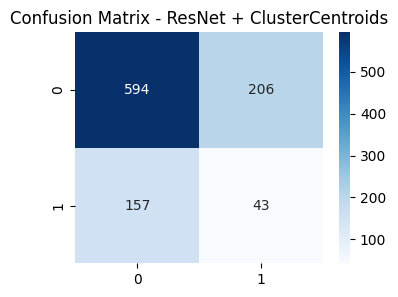

✓ Done: ResNet + ClusterCentroids


In [9]:
from imblearn.under_sampling import ClusterCentroids

print("-" * 30)
print('ResNet + ClusterCentroids (Warning: Slow!)')
print("-" * 30)

best_model_resnet_cc = None
best_score_resnet_cc = 0
best_fold_idx_resnet_cc = -1
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    cc = ClusterCentroids(random_state=42)
    X_res, y_res = cc.fit_resample(X_fold_train, y_fold_train)
    
    model = create_resnet_model(X_res.shape[1])
    model.fit(X_res, y_res, validation_data=(X_fold_val, y_fold_val),
              epochs=50, batch_size=32, verbose=0,
              callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)])
    
    loss, accuracy, precision, recall, auc = model.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_scores.append(accuracy)
    print(f"Fold {fold}: Val Accuracy = {accuracy:.4f}")
    
    if accuracy > best_score_resnet_cc:
        best_score_resnet_cc = accuracy
        best_model_resnet_cc = model
        best_fold_idx_resnet_cc = fold

print(f"Selected model from fold {best_fold_idx_resnet_cc} for test evaluation")
y_pred_proba = best_model_resnet_cc.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()
print('--- Test Set Performance ---')
print(classification_report(y_test, y_pred, digits=4))
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:\n', cm)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - ResNet + ClusterCentroids')
plt.show()

resnet_cc_results = {
    'Model': 'ResNet', 'Sampling': f'ClusterCentroids (Fold {best_fold_idx_resnet_cc})',
    'CV_Accuracy': np.mean(cv_scores), 'CV_Std': np.std(cv_scores),
    'Test_Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred), 'Recall': recall_score(y_test, y_pred),
    'F1_Score': f1_score(y_test, y_pred), 'ROC_AUC': roc_auc_score(y_test, y_pred_proba),
    'TP': confusion_matrix(y_test, y_pred).ravel()[3], 'TN': confusion_matrix(y_test, y_pred).ravel()[0],
    'FP': confusion_matrix(y_test, y_pred).ravel()[1], 'FN': confusion_matrix(y_test, y_pred).ravel()[2]
}
best_model_resnet_cc.save('resnet/models/ResNet_cc_bestfold.h5')
print("✓ Done: ResNet + ClusterCentroids")

------------------------------
ResNet + SMOTETomek
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 1: Val Accuracy = 0.6044


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 2: Val Accuracy = 0.5989


...

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 4: Val Accuracy = 0.6006


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 5: Val Accuracy = 0.5856
Selected model from fold 1 for test evaluation


--- Test Set Performance ---
              precision    recall  f1-score   support

           0     0.7988    0.6900    0.7404       800
           1     0.1974    0.3050    0.2397       200

    accuracy                         0.6130      1000
   macro avg     0.4981    0.4975    0.4901      1000
weighted avg     0.6786    0.6130    0.6403      1000

Confusion Matrix:
 [[552 248]
 [139  61]]


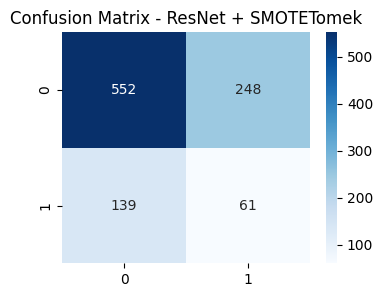

✓ Done: ResNet + SMOTETomek


In [10]:
from imblearn.combine import SMOTETomek

print("-" * 30)
print('ResNet + SMOTETomek')
print("-" * 30)

best_model_resnet_smt = None
best_score_resnet_smt = 0
best_fold_idx_resnet_smt = -1
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    smt = SMOTETomek(random_state=42)
    X_res, y_res = smt.fit_resample(X_fold_train, y_fold_train)
    
    model = create_resnet_model(X_res.shape[1])
    model.fit(X_res, y_res, validation_data=(X_fold_val, y_fold_val),
              epochs=50, batch_size=32, verbose=0,
              callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)])
    
    loss, accuracy, precision, recall, auc = model.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_scores.append(accuracy)
    print(f"Fold {fold}: Val Accuracy = {accuracy:.4f}")
    
    if accuracy > best_score_resnet_smt:
        best_score_resnet_smt = accuracy
        best_model_resnet_smt = model
        best_fold_idx_resnet_smt = fold

print(f"Selected model from fold {best_fold_idx_resnet_smt} for test evaluation")
y_pred_proba = best_model_resnet_smt.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()
print('--- Test Set Performance ---')
print(classification_report(y_test, y_pred, digits=4))
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:\n', cm)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - ResNet + SMOTETomek')
plt.show()

resnet_smt_results = {
    'Model': 'ResNet', 'Sampling': f'SMOTETomek (Fold {best_fold_idx_resnet_smt})',
    'CV_Accuracy': np.mean(cv_scores), 'CV_Std': np.std(cv_scores),
    'Test_Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred), 'Recall': recall_score(y_test, y_pred),
    'F1_Score': f1_score(y_test, y_pred), 'ROC_AUC': roc_auc_score(y_test, y_pred_proba),
    'TP': confusion_matrix(y_test, y_pred).ravel()[3], 'TN': confusion_matrix(y_test, y_pred).ravel()[0],
    'FP': confusion_matrix(y_test, y_pred).ravel()[1], 'FN': confusion_matrix(y_test, y_pred).ravel()[2]
}
best_model_resnet_smt.save('resnet/models/ResNet_smotetomek_bestfold.h5')
print("✓ Done: ResNet + SMOTETomek")

------------------------------
ResNet + SMOTEENN
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 1: Val Accuracy = 0.3761


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 2: Val Accuracy = 0.3228


...

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 4: Val Accuracy = 0.2272


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 5: Val Accuracy = 0.2106
Selected model from fold 1 for test evaluation


--- Test Set Performance ---
              precision    recall  f1-score   support

           0     0.7909    0.3262    0.4619       800
           1     0.1955    0.6550    0.3011       200

    accuracy                         0.3920      1000
   macro avg     0.4932    0.4906    0.3815      1000
weighted avg     0.6718    0.3920    0.4298      1000

Confusion Matrix:
 [[261 539]
 [ 69 131]]


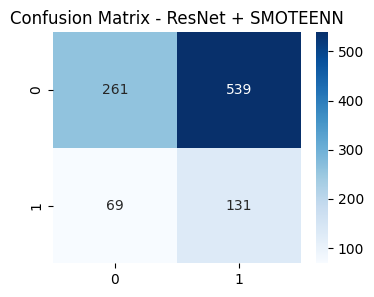

✓ Done: ResNet + SMOTEENN


In [11]:
from imblearn.combine import SMOTEENN

print("-" * 30)
print('ResNet + SMOTEENN')
print("-" * 30)

best_model_resnet_sme = None
best_score_resnet_sme = 0
best_fold_idx_resnet_sme = -1
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    sme = SMOTEENN(random_state=42)
    X_res, y_res = sme.fit_resample(X_fold_train, y_fold_train)
    
    model = create_resnet_model(X_res.shape[1])
    model.fit(X_res, y_res, validation_data=(X_fold_val, y_fold_val),
              epochs=50, batch_size=32, verbose=0,
              callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)])
    
    loss, accuracy, precision, recall, auc = model.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_scores.append(accuracy)
    print(f"Fold {fold}: Val Accuracy = {accuracy:.4f}")
    
    if accuracy > best_score_resnet_sme:
        best_score_resnet_sme = accuracy
        best_model_resnet_sme = model
        best_fold_idx_resnet_sme = fold

print(f"Selected model from fold {best_fold_idx_resnet_sme} for test evaluation")
y_pred_proba = best_model_resnet_sme.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()
print('--- Test Set Performance ---')
print(classification_report(y_test, y_pred, digits=4))
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:\n', cm)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - ResNet + SMOTEENN')
plt.show()

resnet_sme_results = {
    'Model': 'ResNet', 'Sampling': f'SMOTEENN (Fold {best_fold_idx_resnet_sme})',
    'CV_Accuracy': np.mean(cv_scores), 'CV_Std': np.std(cv_scores),
    'Test_Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred), 'Recall': recall_score(y_test, y_pred),
    'F1_Score': f1_score(y_test, y_pred), 'ROC_AUC': roc_auc_score(y_test, y_pred_proba),
    'TP': confusion_matrix(y_test, y_pred).ravel()[3], 'TN': confusion_matrix(y_test, y_pred).ravel()[0],
    'FP': confusion_matrix(y_test, y_pred).ravel()[1], 'FN': confusion_matrix(y_test, y_pred).ravel()[2]
}
best_model_resnet_sme.save('resnet/models/ResNet_smoteenn_bestfold.h5')
print("✓ Done: ResNet + SMOTEENN")

------------------------------
ResNet + ADASYN + Tomek Links
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 1: Val Accuracy = 0.5789


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 2: Val Accuracy = 0.5911


...

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 4: Val Accuracy = 0.6956


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 5: Val Accuracy = 0.6089
Selected model from fold 4 for test evaluation


--- Test Set Performance ---
              precision    recall  f1-score   support

           0     0.7946    0.8512    0.8220       800
           1     0.1678    0.1200    0.1399       200

    accuracy                         0.7050      1000
   macro avg     0.4812    0.4856    0.4810      1000
weighted avg     0.6693    0.7050    0.6856      1000

Confusion Matrix:
 [[681 119]
 [176  24]]


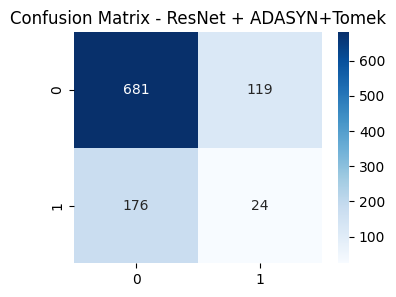

✓ Done: ResNet + ADASYN + Tomek


In [12]:
from imblearn.over_sampling import ADASYN
from imblearn.under_sampling import TomekLinks

print("-" * 30)
print('ResNet + ADASYN + Tomek Links')
print("-" * 30)

best_model_resnet_ada_tomek = None
best_score_resnet_ada_tomek = 0
best_fold_idx_resnet_ada_tomek = -1
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    ada = ADASYN(random_state=42)
    X_res, y_res = ada.fit_resample(X_fold_train, y_fold_train)
    tl = TomekLinks()
    X_res, y_res = tl.fit_resample(X_res, y_res)
    
    model = create_resnet_model(X_res.shape[1])
    model.fit(X_res, y_res, validation_data=(X_fold_val, y_fold_val),
              epochs=50, batch_size=32, verbose=0,
              callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)])
    
    loss, accuracy, precision, recall, auc = model.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_scores.append(accuracy)
    print(f"Fold {fold}: Val Accuracy = {accuracy:.4f}")
    
    if accuracy > best_score_resnet_ada_tomek:
        best_score_resnet_ada_tomek = accuracy
        best_model_resnet_ada_tomek = model
        best_fold_idx_resnet_ada_tomek = fold

print(f"Selected model from fold {best_fold_idx_resnet_ada_tomek} for test evaluation")
y_pred_proba = best_model_resnet_ada_tomek.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()
print('--- Test Set Performance ---')
print(classification_report(y_test, y_pred, digits=4))
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:\n', cm)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - ResNet + ADASYN+Tomek')
plt.show()

resnet_ada_tomek_results = {
    'Model': 'ResNet', 'Sampling': f'ADASYN + Tomek (Fold {best_fold_idx_resnet_ada_tomek})',
    'CV_Accuracy': np.mean(cv_scores), 'CV_Std': np.std(cv_scores),
    'Test_Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred), 'Recall': recall_score(y_test, y_pred),
    'F1_Score': f1_score(y_test, y_pred), 'ROC_AUC': roc_auc_score(y_test, y_pred_proba),
    'TP': confusion_matrix(y_test, y_pred).ravel()[3], 'TN': confusion_matrix(y_test, y_pred).ravel()[0],
    'FP': confusion_matrix(y_test, y_pred).ravel()[1], 'FN': confusion_matrix(y_test, y_pred).ravel()[2]
}
best_model_resnet_ada_tomek.save('resnet/models/ResNet_adasyntomek_bestfold.h5')
print("✓ Done: ResNet + ADASYN + Tomek")

------------------------------
ResNet + Borderline2 + Tomek Links
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 1: Val Accuracy = 0.5917


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 2: Val Accuracy = 0.5889


...

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 4: Val Accuracy = 0.5206


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 5: Val Accuracy = 0.6400
Selected model from fold 5 for test evaluation


--- Test Set Performance ---
              precision    recall  f1-score   support

           0     0.8126    0.7100    0.7578       800
           1     0.2292    0.3450    0.2754       200

    accuracy                         0.6370      1000
   macro avg     0.5209    0.5275    0.5166      1000
weighted avg     0.6959    0.6370    0.6614      1000

Confusion Matrix:
 [[568 232]
 [131  69]]


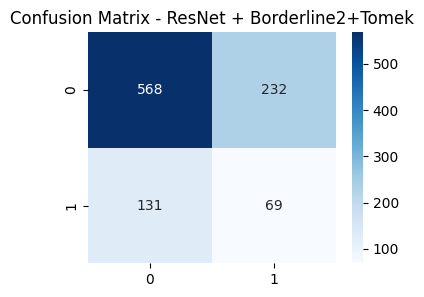

✓ Done: ResNet + Borderline2 + Tomek


In [13]:
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.under_sampling import TomekLinks

print("-" * 30)
print('ResNet + Borderline2 + Tomek Links')
print("-" * 30)

best_model_resnet_bl_tomek = None
best_score_resnet_bl_tomek = 0
best_fold_idx_resnet_bl_tomek = -1
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    bl = BorderlineSMOTE(kind='borderline-2', random_state=42)
    X_res, y_res = bl.fit_resample(X_fold_train, y_fold_train)
    tl = TomekLinks()
    X_res, y_res = tl.fit_resample(X_res, y_res)
    
    model = create_resnet_model(X_res.shape[1])
    model.fit(X_res, y_res, validation_data=(X_fold_val, y_fold_val),
              epochs=50, batch_size=32, verbose=0,
              callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)])
    
    loss, accuracy, precision, recall, auc = model.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_scores.append(accuracy)
    print(f"Fold {fold}: Val Accuracy = {accuracy:.4f}")
    
    if accuracy > best_score_resnet_bl_tomek:
        best_score_resnet_bl_tomek = accuracy
        best_model_resnet_bl_tomek = model
        best_fold_idx_resnet_bl_tomek = fold

print(f"Selected model from fold {best_fold_idx_resnet_bl_tomek} for test evaluation")
y_pred_proba = best_model_resnet_bl_tomek.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()
print('--- Test Set Performance ---')
print(classification_report(y_test, y_pred, digits=4))
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:\n', cm)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - ResNet + Borderline2+Tomek')
plt.show()

resnet_bl_tomek_results = {
    'Model': 'ResNet', 'Sampling': f'Borderline2 + Tomek (Fold {best_fold_idx_resnet_bl_tomek})',
    'CV_Accuracy': np.mean(cv_scores), 'CV_Std': np.std(cv_scores),
    'Test_Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred), 'Recall': recall_score(y_test, y_pred),
    'F1_Score': f1_score(y_test, y_pred), 'ROC_AUC': roc_auc_score(y_test, y_pred_proba),
    'TP': confusion_matrix(y_test, y_pred).ravel()[3], 'TN': confusion_matrix(y_test, y_pred).ravel()[0],
    'FP': confusion_matrix(y_test, y_pred).ravel()[1], 'FN': confusion_matrix(y_test, y_pred).ravel()[2]
}
best_model_resnet_bl_tomek.save('resnet/models/ResNet_bltomek_bestfold.h5')
print("✓ Done: ResNet + Borderline2 + Tomek")

🏆 FINAL COMPARISON TABLE - ResNet (Sorted by Recall)


,Model,Sampling,CV_Accuracy,CV_Std,Test_Accuracy,Precision,Recall,F1_Score,ROC_AUC,TP,TN,FP,FN
0,ResNet,SMOTEENN (Fold 1),0.272333,0.065432,0.392,0.195522,0.655,0.301149,0.486219,131,261,539,69
1,ResNet,NearMiss (Fold 4),0.467111,0.088534,0.554,0.195545,0.395,0.261589,0.508569,79,475,325,121
2,ResNet,RandomUnderSampler (Fold 2),0.573556,0.035776,0.570,0.190860,0.355,0.248252,0.493837,71,499,301,129
3,ResNet,Borderline2 + Tomek (Fold 5),0.586667,0.038147,0.637,0.229236,0.345,0.275449,0.523219,69,568,232,131
4,ResNet,SMOTETomek (Fold 1),0.593778,0.009580,0.613,0.197411,0.305,0.239686,0.510613,61,552,248,139
5,ResNet,SMOTE (Fold 1),0.604556,0.015999,0.610,0.193548,0.300,0.235294,0.495550,60,550,250,140
6,ResNet,ADASYN (Fold 4),0.577889,0.033568,0.639,0.211470,0.295,0.246347,0.527088,59,580,220,141
7,ResNet,ClusterCentroids (Fold 2),0.582556,0.045532,0.637,0.172691,0.215,0.191537,0.456069,43,594,206,157
8,ResNet,ADASYN + Tomek (Fold 4),0.615222,0.041422,0.705,0.167832,0.120,0.139942,0.498878,24,681,119,176
9,ResNet,None (Baseline),0.800000,0.000000,0.800,0.000000,0.000,0.000000,0.511919,0,800,0,200


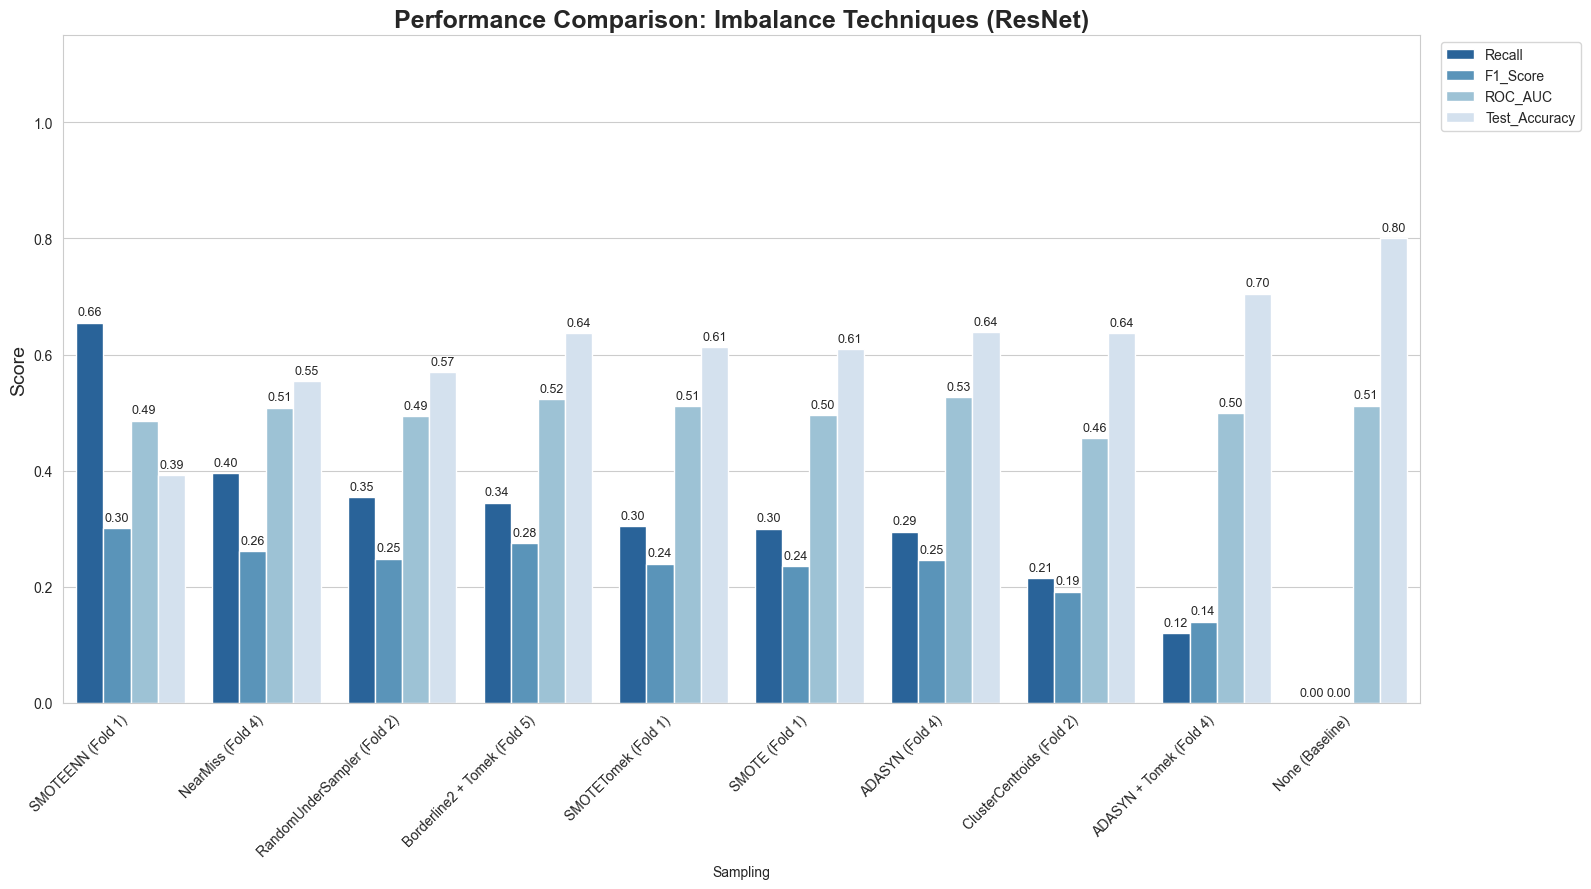

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

resnet_all_results = [
    resnet_baseline_results,
    resnet_smote_results,
    resnet_adasyn_results,
    resnet_rus_results,
    resnet_nearmiss_results,
    resnet_cc_results,
    resnet_smt_results,
    resnet_sme_results,
    resnet_ada_tomek_results,
    resnet_bl_tomek_results
]

df_resnet_results = pd.DataFrame(resnet_all_results)
df_resnet_results = df_resnet_results.sort_values(by='Recall', ascending=False).reset_index(drop=True)

print("=" * 80)
print("🏆 FINAL COMPARISON TABLE - ResNet (Sorted by Recall)")
print("=" * 80)
display(df_resnet_results)

df_resnet_results.to_csv('resnet/resnet_technique_comparison.csv', index=False)

plt.figure(figsize=(16, 9))
sns.set_style("whitegrid")
metrics_to_plot = ['Recall', 'F1_Score', 'ROC_AUC', 'Test_Accuracy']
df_melted = df_resnet_results.melt(id_vars='Sampling', value_vars=metrics_to_plot, var_name='Metric', value_name='Score')

ax = sns.barplot(data=df_melted, x='Sampling', y='Score', hue='Metric', palette='Blues_r')
plt.title('Performance Comparison: Imbalance Techniques (ResNet)', fontsize=18, fontweight='bold')
plt.ylabel('Score', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.ylim(0, 1.15)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)

plt.tight_layout()
plt.savefig('resnet/models/resnet_technique_comparison_chart.png', dpi=300)
plt.show()